# SARIMA: model experiment


## 0. Setup & configuration

In [ ]:

import importlib.util, sys, subprocess
if importlib.util.find_spec("mlflow") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mlflow"], check=True)
    print("mlflow installed.")
else:
    print("mlflow already present.")

mlflow installed.


In [ ]:
import os, sys, json, time, tempfile, warnings

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")
from collections import namedtuple, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

for cat in (ConvergenceWarning, ValueWarning, UserWarning, RuntimeWarning, FutureWarning):
    warnings.filterwarnings("ignore", category=cat)

import mlflow

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

#  Kaggle WMAE: holiday weeks weighted 5x
HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT = 5.0, 1.0

FREQ                 = "W-FRI"
M                    = 52        # seasonal period (weeks per year)
CV_FOLDS             = 3
CV_VALIDATION_WEEKS  = 8
FINAL_HOLDOUT_WEEKS  = 12
MIN_TRAIN_WEEKS      = 90        # a CV fold's train window must exceed this (needs > m=52)
MIN_SEASONAL_WEEKS   = 80        # full-scale: a series needs >= this to attempt a seasonal fit
REP_SERIES_PER_TIER  = 10        # 10 low + 10 medium + 10 high = 30 representative series
N_JOBS               = -1        # parallel workers for the full-scale passes (-1 = all cores)

RUN_FULL_HOLDOUT     = True      # full-data holdout on all ~3,300 series (parallel, a while)
RUN_FULL_SUBMISSION  = True      # fit all ~3,300 series and write the Kaggle submission (parallel)
FULL_HOLDOUT_SAMPLE  = None      # int -> evaluate the holdout on a random N-series sample (faster)

print("Setup complete.")

Setup complete.


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/ML_FINAL_PROJECT/data")
except ModuleNotFoundError:
    DATA_DIR = Path("data")

def _read(name):
    for cand in (DATA_DIR / f"{name}.csv", DATA_DIR / f"{name}.csv.zip"):
        if cand.exists():
            return pd.read_csv(cand)
    raise FileNotFoundError(f"{name}.csv[.zip] not found in {DATA_DIR}")

train    = _read("train")
test     = _read("test")
features = _read("features")
stores   = _read("stores")
print("train", train.shape, "| test", test.shape)

Mounted at /content/drive
train (421570, 5) | test (115064, 4)


In [ ]:
import getpass
DAGSHUB_REPO     = "ZukaCS/ML_FINAL_PROJECT"
DAGSHUB_USERNAME = "dgrig23"
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_REPO}.mlflow")
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass.getpass("DagsHub token: ")
mlflow.set_experiment("SARIMA_Training")
print("tracking:", mlflow.get_tracking_uri())

DagsHub token: ··········
tracking: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow


## 1. Clean & merge

In [ ]:
def clean_and_merge(train_df):
    df = (train_df
          .merge(stores,   on="Store", how="left")
          .merge(features, on=["Store", "Date", "IsHoliday"], how="left"))
    df["Date"] = pd.to_datetime(df["Date"])
    df["Weekly_Sales"] = df["Weekly_Sales"].clip(lower=0)
    df["IsHoliday"] = df["IsHoliday"].astype(float)
    return df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

merged_train = clean_and_merge(train)
print("merged_train", merged_train.shape)

merged_train (421570, 16)


## 2. Representative series selector

Stratified by volume tier, **complete series only**. All seasonal-order selection happens here.
the winner is confirmed on all series in the Final stage (Section 10).

In [ ]:
def select_representative_series(df, n_per_tier=REP_SERIES_PER_TIER, seed=RANDOM_SEED):
    stats = (df.groupby(["Store", "Dept"])["Weekly_Sales"]
               .agg(total_sales="sum", n_weeks="size").reset_index())
    complete = stats[stats["n_weeks"] == int(stats["n_weeks"].max())].copy()
    try:
        complete["volume_tier"] = pd.qcut(complete["total_sales"], 3, labels=["low", "medium", "high"])
    except ValueError:
        complete["volume_tier"] = pd.qcut(complete["total_sales"].rank(method="first"), 3,
                                           labels=["low", "medium", "high"])
    picks = pd.concat([g.sample(min(n_per_tier, len(g)), random_state=seed)
                       for _, g in complete.groupby("volume_tier", observed=True)],
                      ignore_index=True)
    return picks

selected = select_representative_series(merged_train)
selected_keys = list(zip(selected["Store"], selected["Dept"]))
print(f"{len(selected_keys)} representative series "
      f"({selected['volume_tier'].value_counts().to_dict()})")
selected[["Store", "Dept", "total_sales", "n_weeks", "volume_tier"]]

30 representative series ({'low': 10, 'medium': 10, 'high': 10})


,Store,Dept,total_sales,n_weeks,volume_tier
0,15,50,323490.71,143,low
1,35,83,357099.15,143,low
2,28,52,378310.35,143,low
3,33,74,51952.16,143,low
4,32,52,359356.63,143,low
5,3,21,177967.74,143,low
6,28,31,369504.14,143,low
7,30,98,458605.96,143,low
8,37,87,145869.61,143,low
9,7,31,257336.97,143,low


## 3. Weighted MAE (pooled)

In [ ]:
def weighted_mae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.where(np.asarray(is_holiday, dtype=bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT)
    return float(np.average(np.abs(y_true - y_pred), weights=weights))

## 4. Series preprocessor + validation splits



In [ ]:
class SarimaSeriesPreprocessor:
    def build(self, df, store, dept):
        s = (df[(df["Store"] == store) & (df["Dept"] == dept)]
             .sort_values("Date").set_index("Date").asfreq(FREQ))
        if s["Weekly_Sales"].isna().any():
            raise ValueError(f"Store {store} Dept {dept} has gaps. not a complete series.")
        s["IsHoliday"] = s["IsHoliday"].fillna(0).astype(float)
        return s.reset_index()


Split = namedtuple("Split", ["train", "validation"])

def chronological_holdout(series_df, validation_weeks):
    cut = len(series_df) - validation_weeks
    return Split(series_df.iloc[:cut].copy(), series_df.iloc[cut:].copy())

def expanding_window_splits(series_df, n_splits, validation_weeks):
    total, splits = len(series_df), []
    for i in range(n_splits):
        val_end   = total - (n_splits - 1 - i) * validation_weeks
        val_start = val_end - validation_weeks
        if val_start < MIN_TRAIN_WEEKS:
            raise ValueError("series too short for seasonal CV")
        splits.append(Split(series_df.iloc[:val_start].copy(),
                            series_df.iloc[val_start:val_end].copy()))
    return splits

## 5. SeasonalOrderCalibrator + SarimaForecaster

`SeasonalOrderCalibrator` picks one `(p,d,q)(P,D,Q)` per series

In [ ]:
def _fit_sarimax(y, order, seasonal):
    return SARIMAX(y, order=order, seasonal_order=(*seasonal, M),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)


class SeasonalOrderCalibrator:
    """Pick one (order, seasonal) per series on a single window .
    grid: list of ((p,d,q), (P,D,Q)) tuples; m is fixed at M."""
    def __init__(self, grid):
        self.grid = grid

    def calibrate(self, values):
        best, best_score = None, np.inf
        for order, seasonal in self.grid:
            try:
                res = _fit_sarimax(values, order, seasonal)
            except Exception:
                continue
            score = res.aicc if np.isfinite(res.aicc) else np.inf
            if score < best_score:
                best, best_score = (order, seasonal), score
        return best, best_score


class SarimaForecaster:
    """Fit/forecast one series for an ALREADY-chosen (order, seasonal)."""
    def __init__(self, order, seasonal):
        self.order, self.seasonal, self.res = order, seasonal, None

    def fit(self, values):
        self.res = _fit_sarimax(values, self.order, self.seasonal)
        return self

    def forecast(self, steps):
        return np.asarray(self.res.forecast(steps=steps))

## 6. Trial runner

Order calibrated once per series from `cv_splits[0].train`; predictions pooled across all series
per fold; holdout only touched when `do_holdout=True`.

In [ ]:
def run_sarima_trial(keys, grid, label, do_cv=True, do_holdout=False, verbose=True):
    pre = SarimaSeriesPreprocessor()
    cal = SeasonalOrderCalibrator(grid)
    fold_rows, holdout_rows, orders = defaultdict(list), [], []
    fit_s = 0.0

    for store, dept in keys:
        try:
            sdf = pre.build(merged_train, store, dept)
        except ValueError:
            continue
        try:
            hold = chronological_holdout(sdf, FINAL_HOLDOUT_WEEKS)
            cvs  = expanding_window_splits(hold.train, CV_FOLDS, CV_VALIDATION_WEEKS)
        except ValueError:
            continue

        best, aicc = cal.calibrate(cvs[0].train["Weekly_Sales"].values)
        if best is None:
            continue
        order, seasonal = best
        orders.append({"Store": store, "Dept": dept, "order": order, "seasonal": seasonal,
                       "full_order": (order, seasonal), "aicc": aicc})

        if do_cv:
            for fi, fold in enumerate(cvs):
                fc = SarimaForecaster(order, seasonal)
                t = time.perf_counter()
                try:
                    fc.fit(fold.train["Weekly_Sales"].values)
                except Exception:
                    continue
                fit_s += time.perf_counter() - t
                yhat = fc.forecast(len(fold.validation))
                fold_rows[fi].append(pd.DataFrame({
                    "actual": fold.validation["Weekly_Sales"].values, "prediction": yhat,
                    "IsHoliday": fold.validation["IsHoliday"].values}))

        if do_holdout:
            fc = SarimaForecaster(order, seasonal)
            t = time.perf_counter()
            try:
                fc.fit(hold.train["Weekly_Sales"].values)
            except Exception:
                continue
            fit_s += time.perf_counter() - t
            yhat = fc.forecast(len(hold.validation))
            holdout_rows.append(pd.DataFrame({
                "Store": store, "Dept": dept, "Date": hold.validation["Date"].values,
                "actual": hold.validation["Weekly_Sales"].values, "prediction": yhat,
                "IsHoliday": hold.validation["IsHoliday"].values}))

    res = {"label": label, "grid_size": len(grid), "fit_seconds": fit_s,
           "series_used": len(orders), "series_count": len(keys),
           "orders_used": pd.DataFrame(orders)}

    if do_cv:
        fold_wmaes = []
        for fi in sorted(fold_rows):
            pooled = pd.concat(fold_rows[fi], ignore_index=True)
            fold_wmaes.append(weighted_mae(pooled["actual"], pooled["prediction"], pooled["IsHoliday"]))
        res["cv_wmae_mean"] = float(np.mean(fold_wmaes))
        res["cv_wmae_std"]  = float(np.std(fold_wmaes))

    if do_holdout and holdout_rows:
        ph = pd.concat(holdout_rows, ignore_index=True)
        res["holdout_wmae"] = weighted_mae(ph["actual"], ph["prediction"], ph["IsHoliday"])
        res["holdout_mae"]  = float(np.mean(np.abs(ph["actual"] - ph["prediction"])))
        res["holdout_rmse"] = float(np.sqrt(np.mean((ph["actual"] - ph["prediction"]) ** 2)))
        res["pooled_holdout_predictions"] = ph

    if verbose:
        bits = []
        if do_cv:                       bits.append(f"cv_wmae={res['cv_wmae_mean']:,.1f}")
        if do_holdout and holdout_rows: bits.append(f"holdout_wmae={res['holdout_wmae']:,.1f}")
        print(f"[{label}] " + ", ".join(bits) +
              f", fit={fit_s:.1f}s, series={res['series_used']}/{len(keys)}")
    return res

## 7. Seasonal-order grids + timing probe

SARIMA fits are slow, so the probe matters even more here - it tells you the real per-series cost
before you commit to the full loop.

In [ ]:
AIRLINE_ORDER = ((0, 1, 1), (0, 1, 1))   # the classic "airline" SARIMA
BASE_SEASONAL_GRID = [
    ((0, 1, 1), (0, 1, 1)),
    ((1, 1, 0), (0, 1, 1)),
    ((0, 1, 1), (1, 1, 0)),
    ((1, 1, 1), (0, 1, 1)),
]
WIDE_SEASONAL_GRID = BASE_SEASONAL_GRID + [
    ((1, 1, 0), (1, 1, 0)),
    ((0, 1, 0), (0, 1, 1)),
    ((1, 1, 1), (1, 1, 1)),
    ((0, 1, 1), (0, 1, 0)),
]
print(f"airline: 1 config | base grid: {len(BASE_SEASONAL_GRID)} | wide grid: {len(WIDE_SEASONAL_GRID)}")

t0 = time.perf_counter()
_probe = run_sarima_trial(selected_keys[:3], BASE_SEASONAL_GRID, "probe", verbose=False)
per_series = (time.perf_counter() - t0) / 3
print(f"~{per_series:.1f}s per series (base grid calibration + {CV_FOLDS} CV folds)")
print(f"Est. one base-grid trial ({len(selected_keys)} series): ~{per_series*len(selected_keys)/60:.1f} min")

airline: 1 config | base grid: 4 | wide grid: 8
~14.5s per series (base grid calibration + 3 CV folds)
Est. one base-grid trial (30 series): ~7.3 min


## 8. Stage: `SARIMA_Preprocessing` + `SARIMA_Feature_Engineering` + `SARIMA_Feature_Selection`


In [ ]:
with mlflow.start_run(run_name="SARIMA_Preprocessing"):
    mlflow.set_tag("stage", "Preprocessing")
    mlflow.log_params({
        "series_unit": "Store_x_Dept_weekly", "reindex_freq": FREQ, "seasonal_period_m": M,
        "clip_negatives": True, "interpolation": "none (complete series only)",
        "target_transform": "none (raw sales)",
        "evaluation_scope": "stratified_representative_series", "series_per_tier": REP_SERIES_PER_TIER,
    })
    mlflow.log_metrics({"n_representative_series": len(selected_keys), "cv_folds": CV_FOLDS,
                        "cv_validation_weeks": CV_VALIDATION_WEEKS, "final_holdout_weeks": FINAL_HOLDOUT_WEEKS})

with mlflow.start_run(run_name="SARIMA_Feature_Engineering"):
    mlflow.set_tag("stage", "Feature_Engineering")
    mlflow.log_params({"exog_covariates_built": "none (seasonality endogenous, m=52)",
                       "columns_added": "none", "columns_renamed": "none"})

with mlflow.start_run(run_name="SARIMA_Feature_Selection"):
    mlflow.set_tag("stage", "Feature_Selection")
    mlflow.log_params({
        "target_columns_used": json.dumps(["Store", "Dept", "Date", "Weekly_Sales"]),
        "selected_exog_covariates": "none (pure SARIMA, not SARIMAX)",
        "seasonality": "endogenous via (P,D,Q)[52] differencing + seasonal AR/MA",
        "note": "143 weeks = 2.75 annual cycles -> seasonal estimation is statistically thin",
    })
print("preprocessing + feature-engineering + feature-selection stages logged")

🏃 View run SARIMA_Preprocessing at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/b01e462e84c94e94a978a6f2124d164a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9
🏃 View run SARIMA_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/8b2a6a35891f442ab9c15ffff653259a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9
🏃 View run SARIMA_Feature_Selection at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/e3b00e4bfb5d40048947963d9a81fc47
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9
preprocessing + feature-engineering + feature-selection stages logged


## 9. Stage: `SARIMA_CV`: seasonal-order trials



In [ ]:
TRIAL_SPECS = [
    dict(label="A_airline",   grid=[AIRLINE_ORDER]),
    dict(label="B_base_grid", grid=BASE_SEASONAL_GRID),
    dict(label="C_wide_grid", grid=WIDE_SEASONAL_GRID),
]

trials = []
with mlflow.start_run(run_name="SARIMA_CV") as parent:
    mlflow.set_tag("stage", "CV")
    mlflow.log_params({"n_trials": len(TRIAL_SPECS), "cv_folds": CV_FOLDS, "seasonal_period_m": M,
                       "order_selection": "aicc_earliest_fold_only", "metric": "pooled_wmae"})
    for spec in TRIAL_SPECS:
        with mlflow.start_run(run_name=f"SARIMA_CV_{spec['label']}", nested=True):
            t = run_sarima_trial(selected_keys, spec["grid"], spec["label"])
            t["grid"] = spec["grid"]
            mlflow.set_tag("stage", "CV")
            mlflow.log_params({"grid_size": len(spec["grid"]), "seasonal_period_m": M})
            mlflow.log_metrics({"cv_wmae_mean": t["cv_wmae_mean"], "cv_wmae_std": t["cv_wmae_std"],
                                "fit_seconds": t["fit_seconds"], "series_used": t["series_used"]})
            trials.append(t)

comparison = (pd.DataFrame([{"trial": t["label"], "grid_size": t["grid_size"],
                             "cv_wmae_mean": t["cv_wmae_mean"], "cv_wmae_std": t["cv_wmae_std"]}
                            for t in trials])
              .sort_values("cv_wmae_mean").reset_index(drop=True))
comparison

[A_airline] cv_wmae=nan, fit=0.0s, series=0/30
🏃 View run SARIMA_CV_A_airline at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/760929a0e6e94a24b7f114f6f504adf6
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9
[B_base_grid] cv_wmae=nan, fit=0.0s, series=0/30
🏃 View run SARIMA_CV_B_base_grid at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/7a378286c1694af8a84bfbdd13c2bd56
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9
[C_wide_grid] cv_wmae=1,369.2, fit=20.1s, series=30/30
🏃 View run SARIMA_CV_C_wide_grid at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/b2c046d8d96e4e81a7cc4d8f6f62f363
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9
🏃 View run SARIMA_CV at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/fec8431443d445fd808a07d8f9296b6e
🧪 View experiment at: https:

,trial,grid_size,cv_wmae_mean,cv_wmae_std
0,C_wide_grid,8,1369.249517,146.339837
1,A_airline,1,NaN,NaN
2,B_base_grid,4,NaN,NaN


In [ ]:
valid = [t for t in trials if np.isfinite(t["cv_wmae_mean"])]
winner = min(valid, key=lambda t: t["cv_wmae_mean"])
print(f"Winner: {winner['label']} (cv_wmae_mean={winner['cv_wmae_mean']:,.1f})")
_full = winner["orders_used"]["full_order"]
FINAL_ORDER, FINAL_SEASONAL = _full.mode().iloc[0]
FINAL_SEASONAL4 = (*FINAL_SEASONAL, M)
print("Modal order:", FINAL_ORDER, "x", FINAL_SEASONAL4)

Winner: C_wide_grid (cv_wmae_mean=1,369.2)
Modal order: (0, 1, 1) x (0, 1, 0, 52)


## 10. Stage: `SARIMA_Final`

Two holdout numbers logged: **`rep_holdout_wmae`** (30 series) and **`full_holdout_wmae`** (all
~3,300 series, winning order fit once each, parallel, dept-median fallback for short series). Then
the raw-`test` pipeline is logged as an MLflow pyfunc.


In [ ]:
class SarimaPipeline(mlflow.pyfunc.PythonModel):
    """Runs on RAW test.csv. Fits one SARIMA per series from stored history, forecasts to the
    requested dates, seasonal-naive dept-median fallback otherwise."""
    def _setup(self, history, cfg):
        self.cfg = cfg
        history = history.copy(); history["Date"] = pd.to_datetime(history["Date"])
        self.dept_median   = history.groupby("Dept")["Weekly_Sales"].median()
        self.global_median = float(history["Weekly_Sales"].median())
        self._groups = {k: v.sort_values("Date").set_index("Date")
                        for k, v in history.groupby(["Store", "Dept"])}

    def load_context(self, context):
        with open(context.artifacts["config"]) as fh:
            cfg = json.load(fh)
        self._setup(pd.read_csv(context.artifacts["history"]), cfg)

    def _forecast_series(self, store, dept, target_dates):
        s = self._groups.get((store, dept))
        if s is None:
            return None
        s = s.asfreq(FREQ)
        if s["Weekly_Sales"].notna().sum() < self.cfg["min_weeks"]:
            return None
        y = s["Weekly_Sales"].interpolate().ffill().bfill().values
        try:
            res = SARIMAX(y, order=tuple(self.cfg["order"]),
                          seasonal_order=tuple(self.cfg["seasonal4"]),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        except Exception:
            return None
        last = s.index.max()
        steps = int((pd.Timestamp(max(target_dates)) - last).days // 7)
        if steps <= 0:
            return None
        idx = pd.date_range(last + pd.Timedelta(weeks=1), periods=steps, freq=FREQ)
        return pd.Series(np.asarray(res.forecast(steps=steps)), index=idx)

    def predict(self, context, model_input):
        df = model_input.copy(); df["Date"] = pd.to_datetime(df["Date"])
        out = pd.Series(np.nan, index=df.index, dtype=float)
        for (store, dept), grp in df.groupby(["Store", "Dept"], sort=False):
            fb = float(self.dept_median.get(dept, self.global_median))
            preds = self._forecast_series(store, dept, grp["Date"].tolist())
            vals = [float(preds.loc[d]) if (preds is not None and d in preds.index) else fb
                    for d in grp["Date"]]
            out.loc[grp.index] = np.clip(vals, 0, None)
        return out.values

print("SarimaPipeline defined")

SarimaPipeline defined


/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
def _holdout_worker(task, order, seasonal4, min_weeks):
    y, actual, is_holiday, mask, fb = task
    pred = None
    if np.isfinite(y).sum() >= min_weeks:
        try:
            res = SARIMAX(y, order=order, seasonal_order=seasonal4,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            pred = np.asarray(res.forecast(steps=len(actual)))
        except Exception:
            pred = None
    used_fallback = pred is None
    if pred is None:
        pred = np.full(len(actual), fb)
    return actual[mask], np.clip(pred, 0, None)[mask], is_holiday[mask], used_fallback


def evaluate_full_scale(df, order, seasonal4, holdout_weeks=FINAL_HOLDOUT_WEEKS,
                        min_weeks=MIN_SEASONAL_WEEKS, sample=None, n_jobs=N_JOBS):
    dept_median   = df.groupby("Dept")["Weekly_Sales"].median()
    global_median = float(df["Weekly_Sales"].median())
    tasks = []
    for (store, dept), g in df.groupby(["Store", "Dept"], sort=False):
        s = g.sort_values("Date").set_index("Date").asfreq(FREQ)
        if len(s) <= holdout_weeks + 5:
            continue
        train_s, val_s = s.iloc[:-holdout_weeks], s.iloc[-holdout_weeks:]
        actual = val_s["Weekly_Sales"].values
        mask = ~np.isnan(actual)
        if mask.sum() == 0:
            continue
        y  = train_s["Weekly_Sales"].interpolate().ffill().bfill().values
        fb = float(dept_median.get(dept, global_median))
        tasks.append((y, actual, val_s["IsHoliday"].fillna(0).values, mask, fb))
    if sample is not None and sample < len(tasks):
        rng = np.random.default_rng(RANDOM_SEED)
        tasks = [tasks[i] for i in rng.choice(len(tasks), sample, replace=False)]

    t0 = time.perf_counter()
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_holdout_worker)(t, order, seasonal4, min_weeks) for t in tasks)
    a = np.concatenate([r[0] for r in results])
    p = np.concatenate([r[1] for r in results])
    h = np.concatenate([r[2] for r in results])
    n_fallback = sum(r[3] for r in results)
    metrics = {"full_holdout_wmae": weighted_mae(a, p, h),
               "full_holdout_mae":  float(np.mean(np.abs(a - p))),
               "full_holdout_rmse": float(np.sqrt(np.mean((a - p) ** 2)))}
    counts = {"n_series_fit": len(tasks) - n_fallback, "n_series_fallback": n_fallback,
              "n_series_total": len(tasks), "full_scale_seconds": time.perf_counter() - t0}
    return metrics, counts

print("evaluate_full_scale defined")

evaluate_full_scale defined


In [ ]:
run_name = f"SARIMA_Final__{winner['label']}__{FINAL_ORDER}x{FINAL_SEASONAL4}"
with mlflow.start_run(run_name=run_name) as final_run:
    mlflow.set_tag("stage", "Final")
    mlflow.log_params({
        "winner_trial": winner["label"], "final_order": str(FINAL_ORDER),
        "final_seasonal_order": str(FINAL_SEASONAL4), "seasonal_period_m": M,
        "order_selection_criterion": "aicc",
        "order_calibration_window": "earliest_cv_fold_training_only",
        "trials_compared": json.dumps([t["label"] for t in trials]),
        "final_scope": "all_series_full_scale_parallel",
    })

    # (a) representative holdout: 30 complete series
    rep = run_sarima_trial(selected_keys, winner["grid"], winner["label"] + "_rep_holdout",
                           do_cv=False, do_holdout=True)

    metrics_to_log = {"rep_cv_wmae_mean": winner["cv_wmae_mean"],
                      "rep_cv_wmae_std": winner["cv_wmae_std"],
                      "rep_holdout_wmae": rep["holdout_wmae"]}

    # (b) FULL-SCALE holdout: all ~3,300 series, winning order fit once each, in parallel
    if RUN_FULL_HOLDOUT:
        print(f"Full-scale holdout with {FINAL_ORDER}x{FINAL_SEASONAL4} (parallel)...", flush=True)
        full_metrics, full_counts = evaluate_full_scale(
            merged_train, FINAL_ORDER, FINAL_SEASONAL4, sample=FULL_HOLDOUT_SAMPLE)
        metrics_to_log.update(full_metrics); metrics_to_log.update(full_counts)

    mlflow.log_metrics(metrics_to_log)

    # log the raw-test pipeline as a pyfunc artifact (fits lazily per series at predict time)
    with tempfile.TemporaryDirectory() as td:
        hist_path = Path(td) / "history.csv"
        cfg_path  = Path(td) / "config.json"
        merged_train[["Store", "Dept", "Date", "Weekly_Sales"]].to_csv(hist_path, index=False)
        cfg_path.write_text(json.dumps({"order": list(FINAL_ORDER),
                                        "seasonal4": list(FINAL_SEASONAL4),
                                        "min_weeks": MIN_SEASONAL_WEEKS}))
        logged_model = mlflow.pyfunc.log_model(
            name="model", python_model=SarimaPipeline(),
            artifacts={"history": str(hist_path), "config": str(cfg_path)},
            input_example=test.head(5))
        mlflow.set_tag("model_uri", logged_model.model_uri)
    final_run_id = final_run.info.run_id
    MODEL_URI = logged_model.model_uri

print(f"\nRepresentative (30 series):  rep_holdout_wmae = {rep['holdout_wmae']:,.2f}")
if RUN_FULL_HOLDOUT:
    print("Full scale:")
    for k, v in full_metrics.items():
        print(f"  {k}: {v:,.2f}")
    print("Counts:", full_counts)
print("run_id:", final_run_id)
print("model_uri:", MODEL_URI)

[C_wide_grid_rep_holdout] holdout_wmae=1,415.6, fit=7.3s, series=30/30
Full-scale holdout with (0, 1, 1)x(0, 1, 0, 52) (parallel)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:   36.9s
[Parallel(n_jobs=-1)]: Done 284 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 644 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 878 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 1148 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 1454 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 1796 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done 2174 tasks      | elapsed:  8.4min
[Parallel(n_jobs=-1)]: Done 2588 tasks      | elapsed: 10.0min
[Parallel(n_jobs=-1)]: Done 3038 tasks      | elapsed: 11.9min
[Parallel(n_jobs=-1)]: Done 3247 out of 3247 | elapsed: 12.7min finished
2026/07/12 11:36:48 WARNING mlflow.pyfu

🏃 View run SARIMA_Final__C_wide_grid__(0, 1, 1)x(0, 1, 0, 52) at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/0a637b2995c044b38459e85e6fcc6933
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9

Representative (30 series):  rep_holdout_wmae = 1,415.63
Full scale:
  full_holdout_wmae: 1,552.65
  full_holdout_mae: 1,560.30
  full_holdout_rmse: 3,392.20
Counts: {'n_series_fit': 3121, 'n_series_fallback': 126, 'n_series_total': 3247, 'full_scale_seconds': 762.3322998800004}
run_id: 0a637b2995c044b38459e85e6fcc6933
model_uri: models:/m-ec1288d7f5cc42559eb2254f20cf1b6a


## 11. A few holdout forecasts, visually

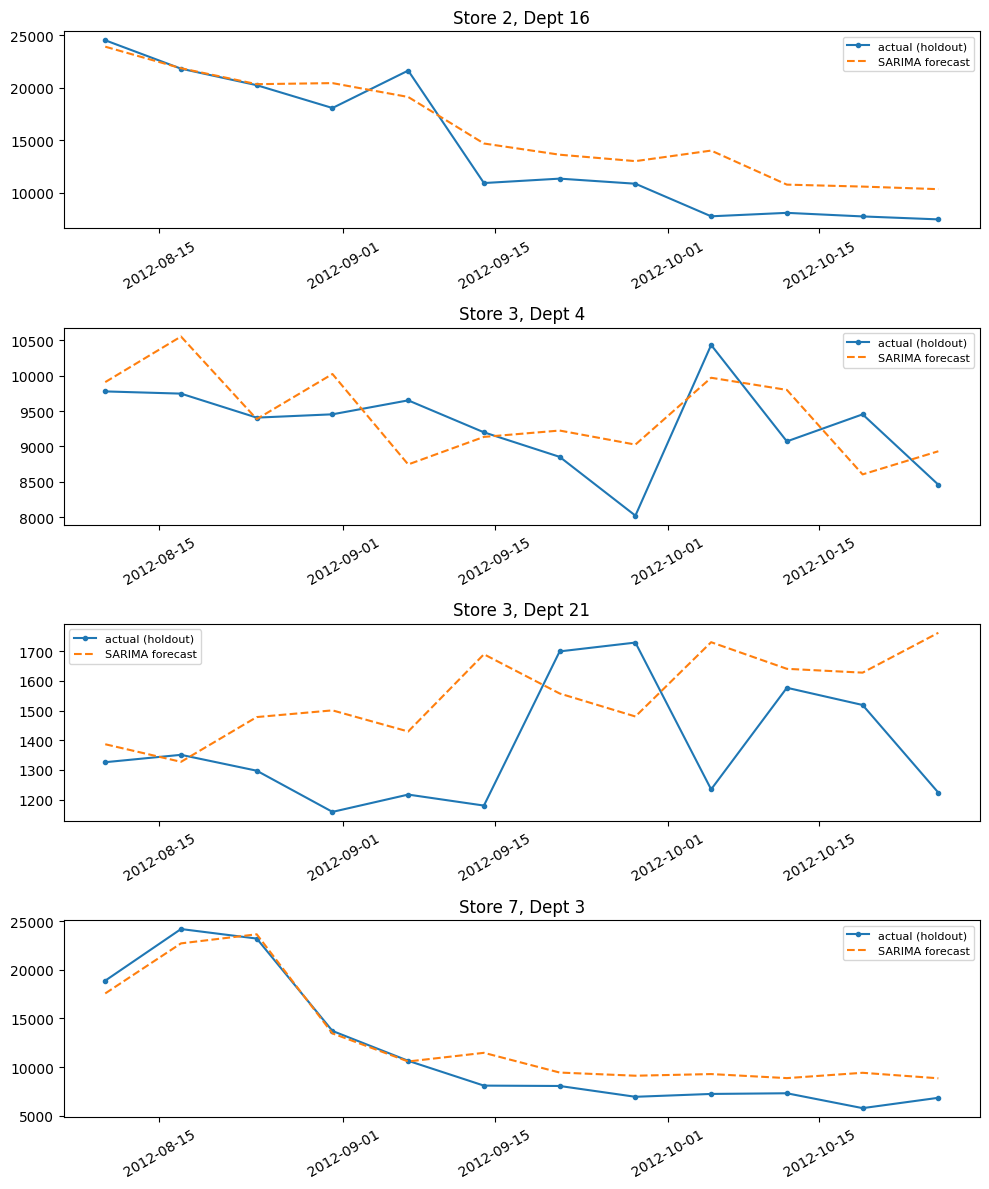

In [ ]:
ph = rep["pooled_holdout_predictions"]
groups = ph.groupby(["Store", "Dept"])
sample = list(groups.groups.keys())[:4]
fig, axes = plt.subplots(len(sample), 1, figsize=(10, 3 * len(sample)))
axes = np.atleast_1d(axes)
for ax, key in zip(axes, sample):
    sub = groups.get_group(key).sort_values("Date")
    ax.plot(sub["Date"], sub["actual"], marker="o", ms=3, label="actual (holdout)")
    ax.plot(sub["Date"], sub["prediction"], ls="--", label="SARIMA forecast")
    ax.set_title(f"Store {key[0]}, Dept {key[1]}"); ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 12. submission file



In [ ]:
def _submit_worker(task, order, seasonal4, min_weeks):
    idxs, dates, y, last, fb = task
    preds = np.full(len(idxs), fb, dtype=float)
    if y is not None and np.isfinite(y).sum() >= min_weeks:
        try:
            res = SARIMAX(y, order=order, seasonal_order=seasonal4,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            steps = int((max(dates) - last).days // 7)
            if steps > 0:
                fc = np.asarray(res.forecast(steps=steps))
                grid = pd.date_range(last + pd.Timedelta(weeks=1), periods=steps, freq=FREQ)
                mp = {d: v for d, v in zip(grid, fc)}
                preds = np.array([mp.get(d, fb) for d in dates], dtype=float)
        except Exception:
            pass
    return idxs, np.clip(preds, 0, None)


if RUN_FULL_SUBMISSION:
    hist = merged_train[["Store", "Dept", "Date", "Weekly_Sales"]].copy()
    hist["Date"] = pd.to_datetime(hist["Date"])
    dept_median   = hist.groupby("Dept")["Weekly_Sales"].median()
    global_median = float(hist["Weekly_Sales"].median())
    hist_groups = {k: v.sort_values("Date").set_index("Date").asfreq(FREQ)
                   for k, v in hist.groupby(["Store", "Dept"])}

    test_ = test.copy(); test_["Date"] = pd.to_datetime(test_["Date"])
    tasks = []
    for (store, dept), grp in test_.groupby(["Store", "Dept"], sort=False):
        fb = float(dept_median.get(dept, global_median))
        s = hist_groups.get((store, dept))
        if s is None:
            tasks.append((grp.index.values, list(grp["Date"]), None, None, fb))
        else:
            y = s["Weekly_Sales"].interpolate().ffill().bfill().values
            tasks.append((grp.index.values, list(grp["Date"]), y, s.index.max(), fb))

    print(f"Forecasting the test set with {FINAL_ORDER}x{FINAL_SEASONAL4} (parallel)...", flush=True)
    results = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(_submit_worker)(t, FINAL_ORDER, FINAL_SEASONAL4, MIN_SEASONAL_WEEKS) for t in tasks)
    out = np.full(len(test), np.nan)
    for idxs, preds in results:
        out[idxs] = preds
    assert not np.isnan(out).any()

    submission = pd.DataFrame({
        "Id": test["Store"].astype(str) + "_" + test["Dept"].astype(str) + "_" + test["Date"].astype(str),
        "Weekly_Sales": np.clip(out, 0, None),
    })
    sub_path = DATA_DIR.parent / "submissions" / "submission_sarima.csv"   # -> Drive
    sub_path.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(sub_path, index=False)
    with mlflow.start_run(run_id=final_run_id):
        mlflow.log_artifact(str(sub_path))
    print("saved to Drive + logged to MLflow:", sub_path)
    display(submission.head())
else:
    print("RUN_FULL_SUBMISSION=False - skipping submission.")

Forecasting the test set with (0, 1, 1)x(0, 1, 0, 52) (parallel)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:   39.9s
[Parallel(n_jobs=-1)]: Done 284 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 644 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 878 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 1148 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 1454 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 1796 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 2174 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 2588 tasks      | elapsed: 10.9min
[Parallel(n_jobs=-1)]: Done 3038 tasks      | elapsed: 12.8min
[Parallel(n_jobs=-1)]: Done 3169 out of 3169 | elapsed: 13.4min finished


🏃 View run SARIMA_Final__C_wide_grid__(0, 1, 1)x(0, 1, 0, 52) at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9/runs/0a637b2995c044b38459e85e6fcc6933
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/9
saved to Drive + logged to MLflow: /content/drive/MyDrive/ML_FINAL_PROJECT/submissions/submission_sarima.csv


,Id,Weekly_Sales
0,1_1_2012-11-02,33928.833437
1,1_1_2012-11-09,12732.313437
2,1_1_2012-11-16,13093.433437
3,1_1_2012-11-23,14954.023437
4,1_1_2012-11-30,19336.263437
